# Statistics Foundations

## 5. Significance (Solutions)

Unless otherwise indicated, you may use simulation or an appropriate probability distribution to answer these questions.

## 5.1 1 die

I am playing a simple dice game where the highest scorer wins.

We are allowed to bring our own dice to the match.

In 100 rolls of my opponent's 6-sided die, she scores a total of 376 pips. 

Is my opponent cheating, or is her die fair?

In [12]:
# H0: die is fair (equal probability of every outcome, i.e. discrete uniform distribution)
# upper tail (suspect bias in favour of higher values)
# alpha = 0.05

In [13]:
# Simulating the experiment

import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)

def rolls(size):
    return(rng.integers(1,7,size=size))

def simulate():
    return(rolls(100).sum())

def plot_simulation(repeats):
    data = np.array([simulate() for i in range(repeats)])
    ks, fs = np.unique(data,return_counts=True)

    plt.figure(figsize=(9, 4))
    ax = plt.gca()

    ax.bar(ks, fs, alpha=0.35, zorder=2)
    ax.set_xlim(200, 501)
#    ax.set_xticks(range(0, 401))
    ax.set_xlabel("total pips")
    ax.set_title("{0} repeats".format(repeats))
    plt.tight_layout()
    plt.show()


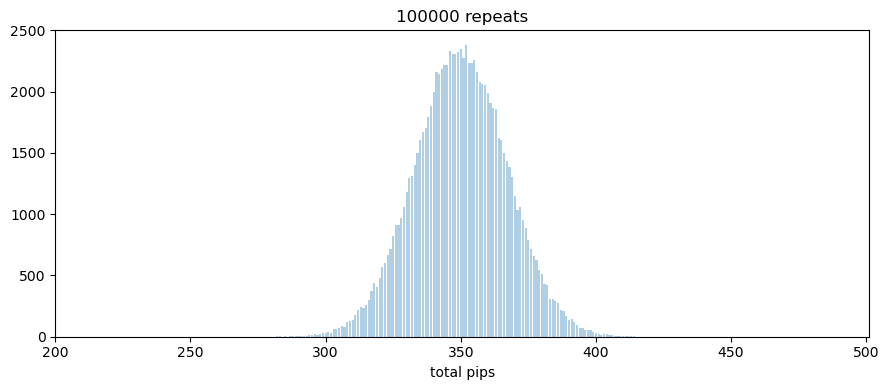

In [14]:
plot_simulation(100000)

In [15]:
# Empirical p-value by simulation

def plot_empirical_p_value_upper_tail(repeats, observed):
    data = np.array([simulate() for i in range(repeats)])
    ks, fs = np.unique(data,return_counts=True)
    obs_index = len(ks)
    for i in range(len(ks)):
        if ks[i] == observed:
            obs_index = i
    
    as_extreme_or_more_extreme = fs[obs_index:].sum()
    p_value = as_extreme_or_more_extreme / repeats

    plt.figure(figsize=(9, 4))
    ax = plt.gca()

    ax.bar(ks[:obs_index], fs[:obs_index], zorder=2)
    ax.bar(ks[obs_index:], fs[obs_index:], alpha=0.35, zorder=2)
 
    

    ax.set_xlim(200, 501)
    ax.set_xlabel("total pips")
    ax.set_title("p_value = {0}".format(p_value))
    plt.tight_layout()
    plt.show()



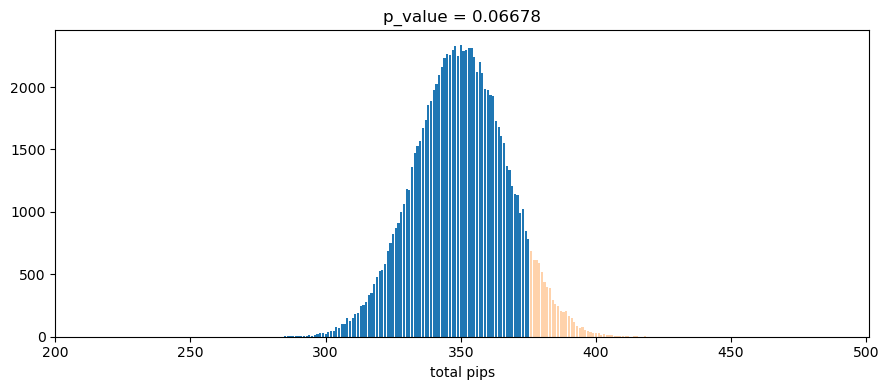

In [16]:

plot_empirical_p_value_upper_tail(repeats=100000, observed=376)

In [17]:
# p > alpha, so the observed result appears to be compatible with H0 - i.e. we do not reject H0.
# (There is no evidence for cheating in this case)

In [18]:
# Alternative solution by known probability distribution.

from scipy.stats import randint
from scipy.stats import norm

# A single roll is modelled as a discrete uniform distribution.
# https://en.wikipedia.org/wiki/Discrete_uniform_distribution

one_roll = randint(1, 7)

# We can approximate the (discrete) distribution of total pips as a normal distribution with parameters
# mu = 100 * mean(one roll)
# sigma^2 = 100 * var(one roll)
# => sigma = 10 * std(one roll)

mu = 100 * one_roll.mean()
sigma = 10 * one_roll.std()

hundred_rolls = norm(mu, sigma)

# The observed value in the experiment is 376 pips
# The p-value is the area under this distribution for x > 375.5 (with continuity correction)
# https://en.wikipedia.org/wiki/Continuity_correction

pval = 1 - hundred_rolls.cdf(375.5)
print(pval)


0.06770195847227778


## 5.2 2 dice

We go on to play a different game using two (6-sided) dice.

This time, the winner is the first person to roll a double 1 ("snake eyes").

<div>
<img src="../figures/snake_eyes.jpg" width="600"/>
</div>

My opponent uses different dice for this game.

In 100 rolls of 2 dice, she gets "snake eyes" 7 times.

Is she cheating?

In [19]:
# H0: both dice are fair. Chance of snake eyes = 1/6 * 1/6 = 1/36
# use upper tail (again suspect cheating towards higher incidence)
# alpha = 0.05

In [20]:
# use binomial CDF directly
from scipy.stats import binom

K = 7

# the lower tail is easy
print("lower tail p =", binom.cdf(K, n=100, p=1.0/36.0))

# but the upper tail we need to think about a bit
print("upper tail p =", 1.0 - binom.cdf(K - 1, n=100, p=1.0/36.0))


lower tail p = 0.993131432175789
upper tail p = 0.021741726383814997


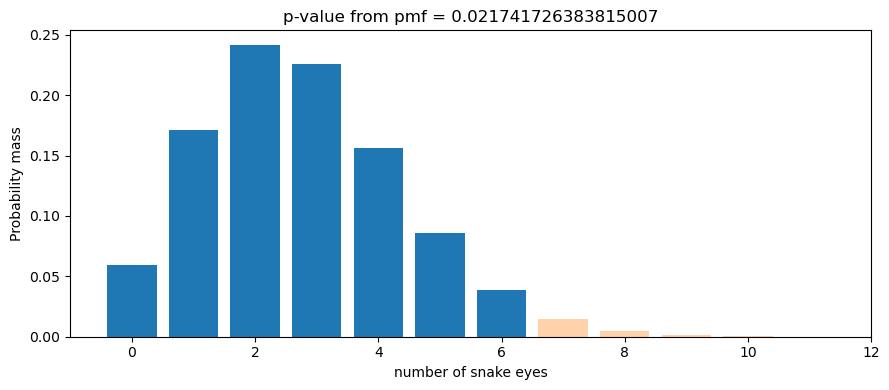

In [21]:
import math

NUM_TRIALS = 100
P = 1.0/36.0

def binom_pmf(k, p, n=100):
    """Binomial pmf for X ~ Bin(n, p)"""
    return math.comb(n, k) * (p**k) * ((1-p)**(n-k))

def plot_binomial_upper_tail(observed):
    ks = np.arange(0, NUM_TRIALS+1)
    probs = np.array([binom_pmf(k, P, NUM_TRIALS) for k in ks])

    as_extreme_or_more_extreme = probs[observed:].sum()
    p_value = as_extreme_or_more_extreme / 1.0  # pmf sums to 1

    plt.figure(figsize=(9, 4))
    ax = plt.gca()

    
    ax.bar(ks[:observed], probs[:observed], zorder=2)
    ax.bar(ks[observed:], probs[observed:], alpha=0.35, zorder=2)


    ax.set_xlim(-1, 12)
    ax.set_xlabel("number of snake eyes")
 #   ax.set_xticks(range(0, NUM_TRIALS + 1))
    ax.set_ylabel("Probability mass")
    ax.set_title("p-value from pmf = {}".format(p_value))
    plt.tight_layout()
    plt.show()

plot_binomial_upper_tail(observed=7)

## 5.3 Incidence rate

In 2024 there were a total of 109 [homicides](https://www.london.gov.uk/londons-homicide-rate-capita-lowest-records-began-having-recorded-its-lowest-homicide-figures-eleven) in London.

In 2025 there were a total of 97 homicides in London.

(a) Did the rate of homicides reduce from 2024 to 2025?

In [22]:
# H0: a Poisson distribution with rate 109 per year
# We take the lower tail (looking at a reduction in rate)
# alpha = 0.05

from scipy import stats

pval = stats.poisson.cdf(97, 109)
pval

np.float64(0.13447244112893836)

In [23]:
# p > alpha, so we do not reject H0
# The observed value does not indicate a significant reduction in rate.

Of course, the population of London changed also. The [estimated populations](https://www.macrotrends.net/global-metrics/cities/22860/london/population) are

2024: 9,748,000 people

2025: 9,841,000 people

(b) Did London's per-capita rate of homicides reduce from 2024 to 2025?

In [24]:
pop_2024 = 9748000
pop_2025 = 9841000

pval = stats.poisson.cdf(97, 109 * pop_2025/pop_2024 )
pval

np.float64(0.11447921808184969)

In [25]:
# again p > alpha, so we do not reject H0

In 2026 there have been 28 homicides recorded in London up to April 13th.

The estimated population of London is currently 9,927,000 people

(c) has the per-capita rate of homicides in London increased since 2025?

In [26]:
# April 13 is the 103rd day of the year
# We need the upper tail to test for an increase in rate

pop_2026 = 9927000

pval = 1.0 - stats.poisson.cdf(28 - 1, 97 * pop_2026/pop_2025 * 103/365 )
pval

np.float64(0.4957782375083418)

In [27]:
# again p > alpha, so we do not reject H0

You can read more about these statistics [here](https://www.theguardian.com/uk-news/2026/jan/12/why-londons-lowest-rate-in-more-than-a-decade-is-drawing-attention).

## 5.4 Skimpflation

Aida is on holiday and I am temporarily in charge of the coffee house.

You buy 5 bags of ground coffee from me, which you measure as having the following net weights in grams:


In [28]:
weights = np.array([198.5, 197.5, 200.6 , 198.4, 195.9])

Recall that the distribution of bag weights is supposed to follow a Gaussian:
$$
X \sim \cal{N}(\mu, {\sigma}^2)
$$

with $\mu = 200$ g, $\sigma = 4$ g

Have I tampered with the grinder to make it dispense less coffee than before?


In [29]:
# H0: the grinder settings are as before
# alpha = 0.05

# compare the mean of the observed weights to an empirical distribution
MU = 200
SIGMA = 4
N_BAGS = 5

def simulate():
    w = stats.norm.rvs(MU, SIGMA, N_BAGS)
    return w.mean()


In [30]:
def plot_simulation(repeats):
    data = np.array([simulate() for i in range(repeats)])

    plt.figure(figsize=(9, 4))
    ax = plt.gca()

    ax.hist(data, alpha=0.35, zorder=2, bins=100)
#    ax.set_xlim(200, 501)
#    ax.set_xticks(range(0, 401))
    ax.set_xlabel("mean weight of 5 bags")
    ax.set_title("{0} repeats".format(repeats))
    plt.tight_layout()
    plt.show()

In [31]:
def plot_empirical_p_value_lower_tail(repeats, observed):
    data = np.array([simulate() for i in range(repeats)])
    
    as_extreme_or_more_extreme = data[data <= observed]
    p_value = len(as_extreme_or_more_extreme) / repeats

    plt.figure(figsize=(9, 4))
    ax = plt.gca()

    ax.hist(data, alpha=0.35, zorder=2, bins=100)
    ax.vlines(observed, 0, 500) # mark the observed value with a line

    #ax.set_xlim(200, 501)
    ax.set_xlabel("mean of 5 bags")
    ax.set_title("p_value = {0}".format(p_value))
    plt.tight_layout()
    plt.show()

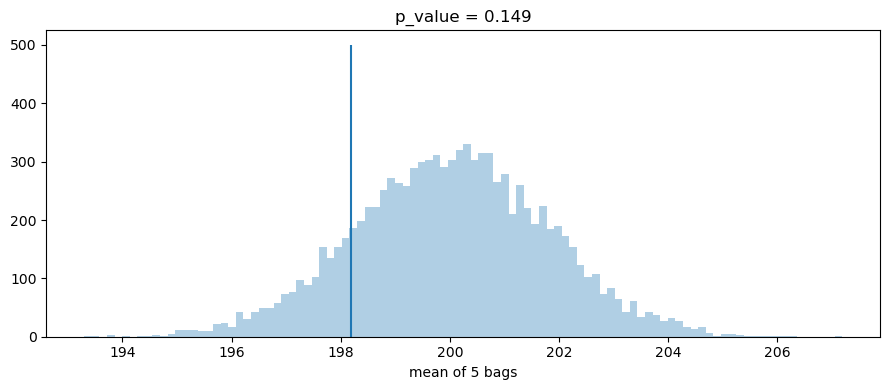

In [32]:
plot_empirical_p_value_lower_tail(10000,weights.mean())

In [33]:
# p > alpha so the machine does not appear to have been tampered with.

In [34]:
# Alternatively, by the central limit theorem, 
# this empirical distribution should correspond to:

MU_ = MU
SIGMA_ = SIGMA / np.sqrt(N_BAGS)

In [35]:
pval = stats.norm.cdf(weights.mean(), MU_, SIGMA_)
print("p =", pval)

p = 0.1544789923560374


## 5.5 Chromosome

There are [364](https://www.ncbi.nlm.nih.gov/gene/?term=human%5BORGN%5D+AND+7283%5BGO%5D) human genes annotated as being part of the "spermatogenesis" biological process ([GO:0007283](https://amigo.geneontology.org/amigo/term/GO:0007283)).


Of these, [10](https://www.ncbi.nlm.nih.gov/gene/?term=Y%5BCHR%5D+AND+human%5BORGN%5D+AND+7283%5BGO%5D) are located the Y chromosome.

There are in total [193863](https://www.ncbi.nlm.nih.gov/gene/?term=human%5BORGN%5D) annotated human genes.


Of these, [1626](https://www.ncbi.nlm.nih.gov/gene/?term=Y%5bCHR%5d+AND+human%5bORGN%5d) genes are located on the Y chromosome.

Are genes associated with spermatogenesis over-represented on the Y chromosome?

(a) Use a simulation to find an empirical p-value.


In [36]:
N_GENES = 193863
N_Y = 1626
N_PROCESS = 364
N_OBS = 10

genome = np.zeros(N_GENES, dtype=int)
genome[:N_PROCESS] = 1

rng = np.random.default_rng()

def simulate():
    return(rng.permuted(genome)[:N_Y].sum())

In [37]:
# Empirical p-value by simulation

def plot_empirical_p_value_upper_tail(repeats, observed):
    data = np.array([simulate() for i in range(repeats)])
    ks, fs = np.unique(data,return_counts=True)
    obs_index = len(ks)
    for i in range(len(ks)):
        if ks[i] == observed:
            obs_index = i
    
    as_extreme_or_more_extreme = fs[obs_index:].sum()
    p_value = as_extreme_or_more_extreme / repeats

    plt.figure(figsize=(9, 4))
    ax = plt.gca()

    ax.bar(ks[:obs_index], fs[:obs_index], zorder=2)
    ax.bar(ks[obs_index:], fs[obs_index:], alpha=0.35, zorder=2)
 
    #ax.set_xlim(200, 501)
    ax.set_xlabel("spermatogenesis genes on Y chromosome")
    ax.set_title("p_value = {0}".format(p_value))
    plt.tight_layout()
    plt.show()



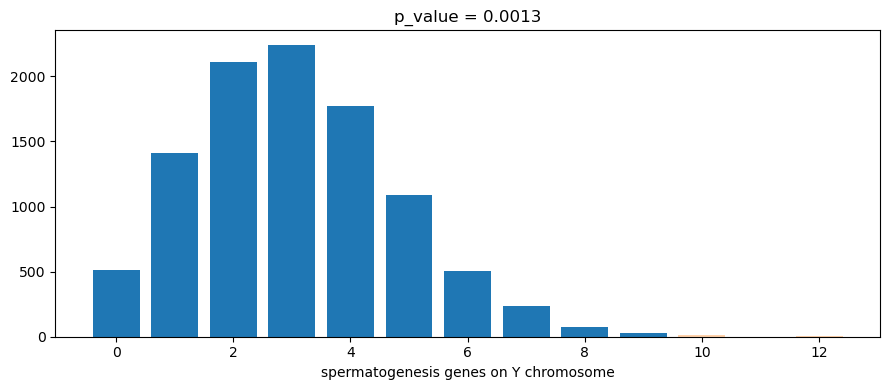

In [38]:
plot_empirical_p_value_upper_tail(10000, N_OBS)

(b) Use the [hypergeometric distribution](https://en.wikipedia.org/wiki/Hypergeometric_distribution) to find an exact p-value.

*Hint*: you could use [`scipy.stats.hypergeom`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.hypergeom.html) to build the pmf.

In [39]:
from scipy import stats
pval = 1 - stats.hypergeom.cdf(N_OBS - 1, N_GENES, N_PROCESS, N_Y)
print ("p =", pval)

p = 0.001163989780311292


## 5.6 Penguin populations

In the penguins data (`data/penguins.csv`), the Adelie species is observed on all 3 islands.

Do the Adelie populations on Dream and Torgersen differ significantly in their body mass?

Use a simulation.

In [40]:
import pandas as pd

penguins = pd.read_csv("../data/penguins.csv")
penguins.head()

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [41]:
# We will investigate the absolute difference in the means of body mass 
# for the two groups of penguins.

# H0: the absolute difference in the means is zero
# alpha = 0.05
# By taking the absolute value, we can derive the p-value from the upper tail

import numpy as np

adelie = penguins[ penguins['species'] == "Adelie" ]
adelie_dream = adelie[ adelie['island'] == "Dream" ]
adelie_torgersen = adelie[ adelie['island'] == "Torgersen" ]

abs_diff = np.abs( adelie_dream.body_mass_g.mean() 
                    - adelie_torgersen.body_mass_g.mean())

In [42]:
abs_diff

np.float64(17.97969187675062)

In [43]:
# One option for our simulation of H0 is to look at randomly splitting the
# data into two groups of the same sizes as the island populations.

# This has the advantage that it does not rely on any assumptions about the shape of the
# body mass distribution.

DATA = pd.concat([adelie_dream, adelie_torgersen])
N_DREAM = len(adelie_dream)

def random_split(data, n):
    shuffled = data.sample(len(data))
    set_0 = shuffled[:n]
    set_1 = shuffled[n:]
    return( (set_0, set_1) )

def simulate():
    (set_0, set_1) = random_split(DATA, N_DREAM)
    return(np.abs(set_0['body_mass_g'].mean() - set_1['body_mass_g'].mean()))

def plot_simulation(repeats):
    data = np.array([simulate() for i in range(repeats)])

    plt.figure(figsize=(9, 4))
    ax = plt.gca()

    ax.hist(data, alpha=0.35, zorder=2, bins=np.arange(0, 350, 10))
    ax.set_xlabel("absolute difference / g")
    ax.set_title("{0} repeats".format(repeats))
    plt.tight_layout()
    plt.show()

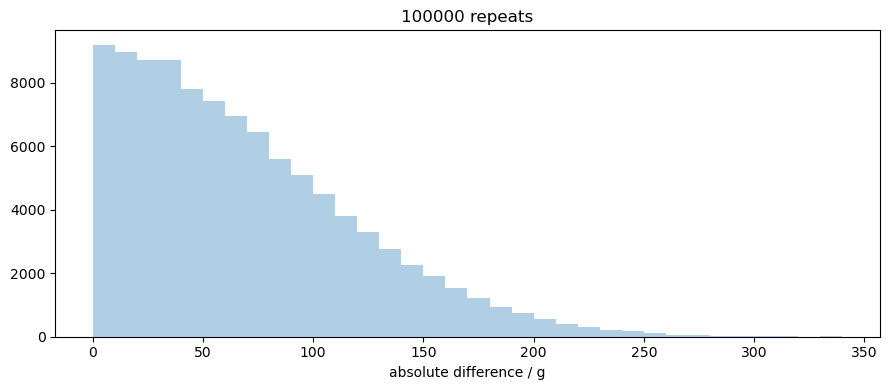

In [44]:
plot_simulation(100000)

In [45]:
def plot_empirical_p_value_upper_tail(repeats, observed):
    data = np.array([simulate() for i in range(repeats)])
    
    as_extreme_or_more_extreme = data[data >= observed]
    p_value = len(as_extreme_or_more_extreme) / repeats

    plt.figure(figsize=(9, 4))
    ax = plt.gca()

    ax.hist(data, alpha=0.35, zorder=2, bins=np.arange(0, 350, 10))
    ax.vlines(observed, 0, 10000) # mark the observed value with a line

    #ax.set_xlim(200, 501)
    ax.set_xlabel("absolute difference / g")
    ax.set_title("p_value = {0}".format(p_value))
    plt.tight_layout()
    plt.show()



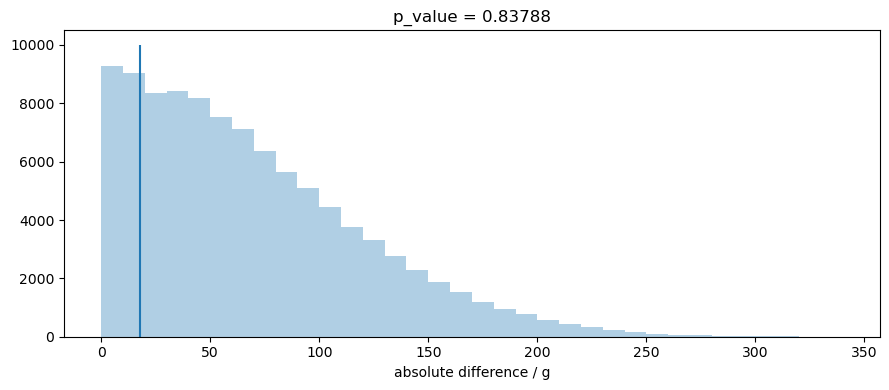

In [46]:
plot_empirical_p_value_upper_tail(100000, abs_diff)

In [47]:
# We can compare to the simulation under the assumption 
# of a normal distribution for body mass

MU = DATA['body_mass_g'].mean()
SIGMA = DATA['body_mass_g'].std()
N_TORGERSEN = len(adelie_torgersen)

def simulate():
    set_0 = np.random.normal(MU, SIGMA, N_DREAM)
    set_1 = np.random.normal(MU, SIGMA, N_TORGERSEN) 
    return(np.abs(set_0.mean() - set_1.mean()))


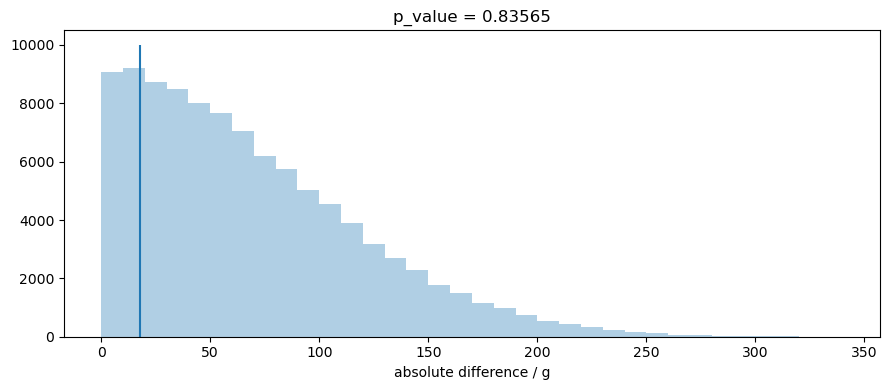

In [48]:

plot_empirical_p_value_upper_tail(100000, abs_diff)

In [49]:
from scipy.stats import ttest_ind
ttest_ind(adelie_dream['body_mass_g'], adelie_torgersen['body_mass_g'], nan_policy='omit')

TtestResult(statistic=np.float64(-0.20624183279962707), pvalue=np.float64(0.8370013888792112), df=np.float64(105.0))